In [74]:
import Random
import StatsPlots

using CairoMakie
using Distributions
using Statistics
using StateSpaceModels
using PairPlots
using TransformVariables
using UnPack
using LogDensityProblems
using TransformedLogDensities
using AdaptiveMCMC
using MCMCChains
set_theme!(
    fontsize = 18,
    Axis = (; xgridvisible = false, ygridvisible = false,
            topspinevisible = false, rightspinevisible = false),
    Legend = (; framevisible = false))

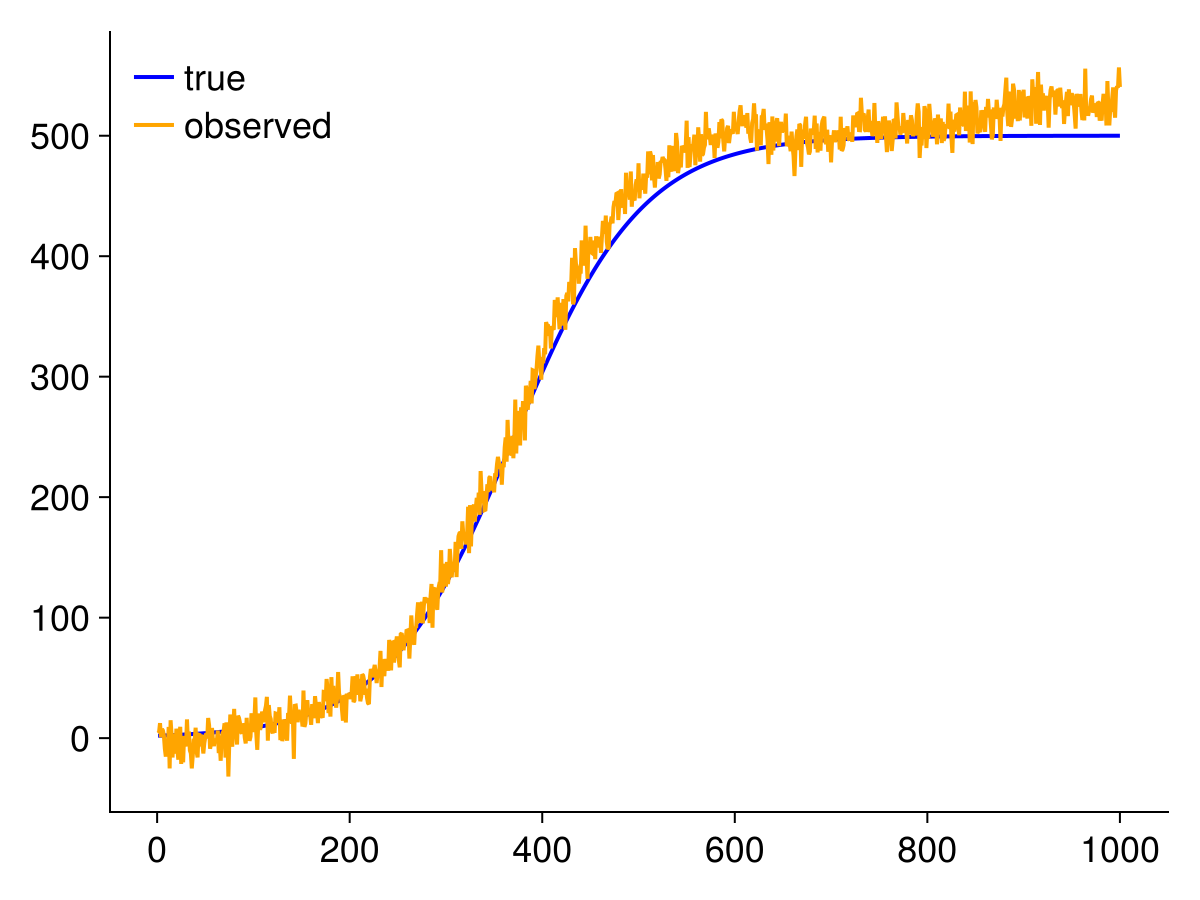

In [99]:
function generate_noise(n, σ_η, σ_ν)
    ν = rand(Normal(0, σ_ν), n)
    η = rand(Normal(0, σ_η), n)
    
    ϵ = zeros(n)
    μ = zeros(n)
    
    μ[1] = ν[1]
    
    for i in 2:n
        μ[i] = μ[i-1] + ν[i]
    end
    
    for i in 1:n
        ϵ[i] = μ[i] + η[i]
    end
    
    return ϵ
end


function simulate_model(p, T; u0 = 2 )
    x = zeros(T)
    x[1] = u0
    
    for t in 2:T
        x[t] = (1 + p.r*(1 -  x[t-1] / p.K)) * x[t-1]
    end
    
    return x
end

sigma_nu = 10
sigma_eta = 1
Random.seed!(1)
real_p = (r = 0.015, K = 500, σ²ₒ = sigma_nu ^ 2, σ²ₚ = sigma_eta ^ 2)
T = 1000

x = simulate_model(real_p, T)
y = x + generate_noise(T, sigma_nu, sigma_eta)
 
let 
    fig = Figure()
    ax = Axis(fig[1, 1], yticks = 0:100:500, xticks = 0:200:1000)
    lines!(1:T, x, color = :blue, linewidth = 2, label = "true")
    lines!(1:T, y, color = :orange, linewidth = 2, label = "observed")
    axislegend(ax; position = :lt)
    fig
end


In [109]:
my_priors = (;
    r = truncated(Normal(0.1, 0.1); lower = 0),
    K = truncated(Normal(500, 500), lower = 0),
    σ²ₒ = truncated(Normal(0, 500); lower = 0),
    σ²ₚ = truncated(Normal(0, 500); lower = 0))

struct StateSpaceMod
    ts::UnitRange{Int64} 
    y::Vector{Float64}
    prior_dists::NamedTuple
    nparameter::Int64
    transformation
end

function (problem::StateSpaceMod)(θ)
    @unpack ts, y, prior_dists = problem
    @unpack r, K, σ²ₒ, σ²ₚ  = θ
    
    logprior = 0
    for k in keys(prior_dists)
        logprior += logpdf(prior_dists[k], θ[k])
    end
    
    if logprior ==  -Inf
        return -Inf
    end
        
    loglikelihood = -Inf
    xs = zeros(length(ts))
    
    for t in ts
        # process equation
        x_last = t == 1 ? 2.0 : xs[t-1]
        xs[t] = (1 + r*(1 - x_last/K)) * x_last
    end
    
    mod1 = LocalLevel(y .- xs)
    fix_hyperparameters!(mod1, Dict("sigma2_ε" => σ²ₒ, "sigma2_η" => σ²ₚ))
    mod1.hyperparameters.unconstrained_values = [sqrt(σ²ₒ), sqrt(σ²ₚ)]
    loglikelihood = loglike(mod1)
    
    if isnan(loglikelihood)
        return -Inf
    end
    
    return loglikelihood + logprior
end

function sample_prior(problem; transform_p = false)
    @unpack ts, prior_dists, transformation = problem
    
    x = []
    for k in keys(prior_dists)
        push!(x, rand(prior_dists[k]))
    end
    
    p = (; zip(keys(prior_dists), x)...)
    if transform_p 
        return inverse(transformation, p)
    end
        
    return p      
end    


function sample_initial_values(prob, sol; transform_p = false)
    @unpack ts, prior_dists, transformation = prob
    @unpack parameter = sol
    
    x = []
    for k in keys(prior_dists)
        push!(x, (1 + rand(Normal(0.0, 0.01))) * parameter[k])
    end
    
    p = (; zip(keys(prior_dists), x)...)
    if transform_p 
        return inverse(transformation, p)
    end
        
    return p      
end


function post_pred(chn, ts; noise = false)
    p = get(chn; section=:parameters)
    nsamples = length(p[1])
    
    T = length(ts)
    X = Array{Float64}(undef, T, nsamples)

    for i in 1:nsamples
        x = Array{Float64}(undef, T)
        r = p.r[i]
        K = p.K[i]

        for t in ts
            x_lastt = t == 1 ? 2.0 : x[t-1]
            x[t] = (1 + r*(1 - x_lastt/K)) * x_lastt
        end
        
        if noise
            x .+= generate_noise(T, sqrt(p.σ²ₒ[i]), sqrt(p.σ²ₚ[i]))
        end
        
        X[:, i] = x
    end
    

    mapslices(x_t -> quantile(x_t, [0.025, 0.25, 0.5, 0.75, 0.975]), X, dims = 2)
end


my_transform = as((r = asℝ₊, K = asℝ₊, σ²ₒ = asℝ₊, σ²ₚ = asℝ₊))
problem = StateSpaceMod(1:T, y, my_priors, 4, my_transform)

ℓ = TransformedLogDensity(problem.transformation, problem)
posterior(x) = LogDensityProblems.logdensity(ℓ, x)
posterior(sample_prior(problem; transform_p = true))

-4742.251424965826

In [110]:
nsamples = 20000
nchains = 4
L = 1
thin = 1
nparameter = problem.nparameter
post_raw = zeros(nchains, nparameter, nsamples ÷ thin)

Threads.@threads for n in 1:nchains
    init_x = sample_prior(problem; transform_p = true)
    # init_x = sample_initial_values(problem, true_solution; transform_p = true)
    out = adaptive_rwm(init_x, posterior, nsamples; 
                       algorithm=:ram, b = 1, L, thin, progress = false)
    post_raw[n, :, :] = out.X
end

In [111]:
post = zeros(nsamples ÷ thin, nparameter, nchains)
for c in 1:nchains
    for i in 1:(nsamples ÷ thin)
        post[i, :, c] .= collect(transform(problem.transformation, post_raw[c, :, i])) 
    end
end

p_names = collect(keys(problem.prior_dists))
burnin = nsamples ÷ thin ÷ 2

chn = Chains(post[burnin:end, :, :], collect(keys(my_priors)))

Chains MCMC chain (10001×4×4 Array{Float64, 3}):

Iterations        = 1:1:10001
Number of chains  = 4
Samples per chain = 10001
parameters        = r, K, σ²ₒ, σ²ₚ

Summary Statistics
  parameters       mean       std      mcse    ess_bulk    ess_tail      rhat  ⋯
      Symbol    Float64   Float64   Float64     Float64     Float64   Float64  ⋯

           r     0.0151    0.0002    0.0000   2952.6196   3571.0465    1.0012  ⋯
           K   521.5190   18.8344    0.3323   3222.6491   3791.9803    1.0010  ⋯
         σ²ₒ   107.2618    5.0111    0.0948   2787.6763   4170.6066    1.0007  ⋯
         σ²ₚ     1.0408    0.3119    0.0074   1693.2527   2220.6066    1.0014  ⋯
                                                                1 column omitted

Quantiles
  parameters       2.5%      25.0%      50.0%      75.0%      97.5% 
      Symbol    Float64    Float64    Float64    Float64    Float64 

           r     0.0147     0.0150     0.0151     0.0153     0.0156
           K   483.5859   509.3

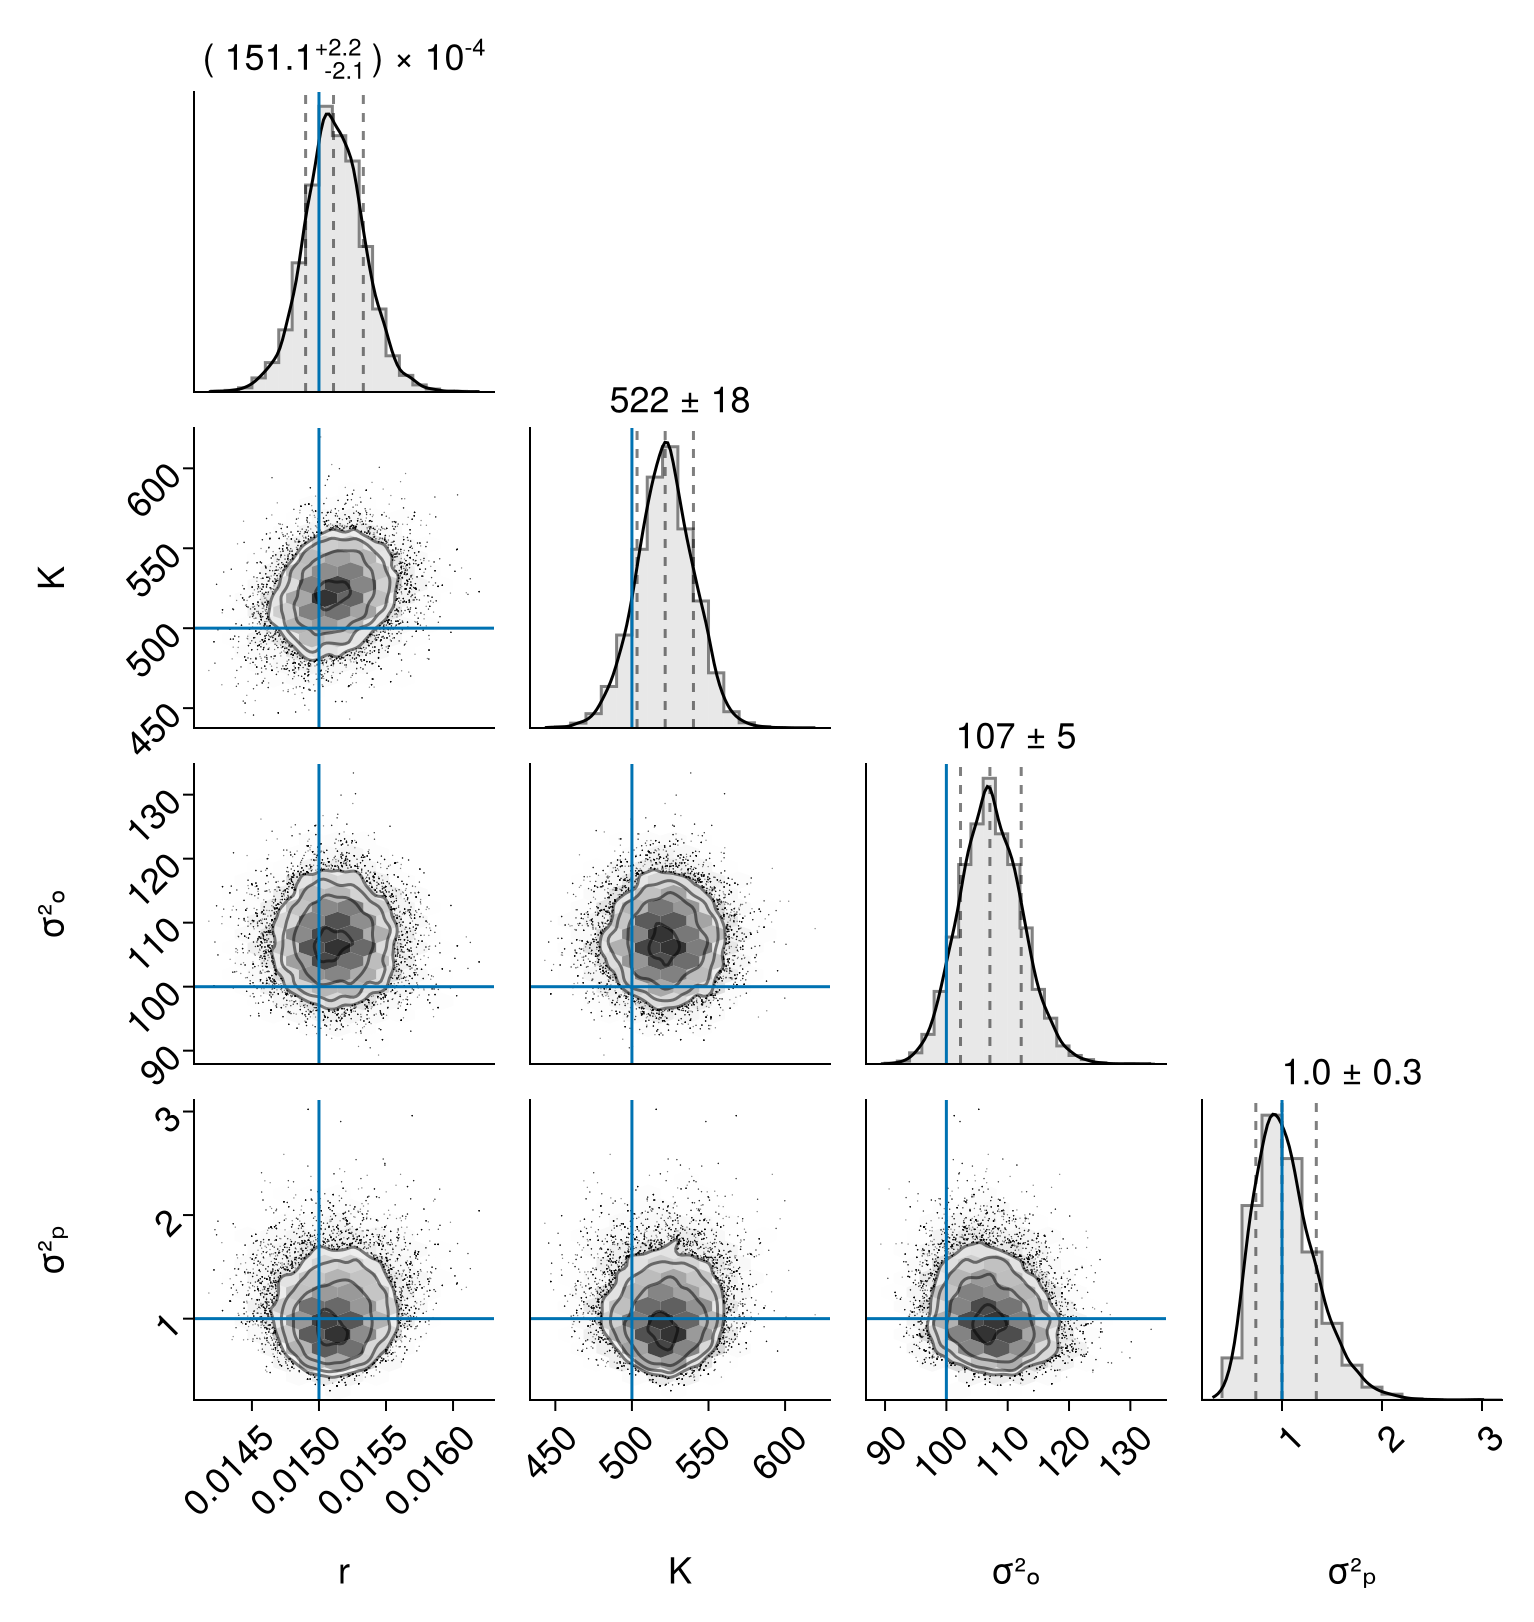

In [112]:
pairplot(chn, PairPlots.Truth(real_p))

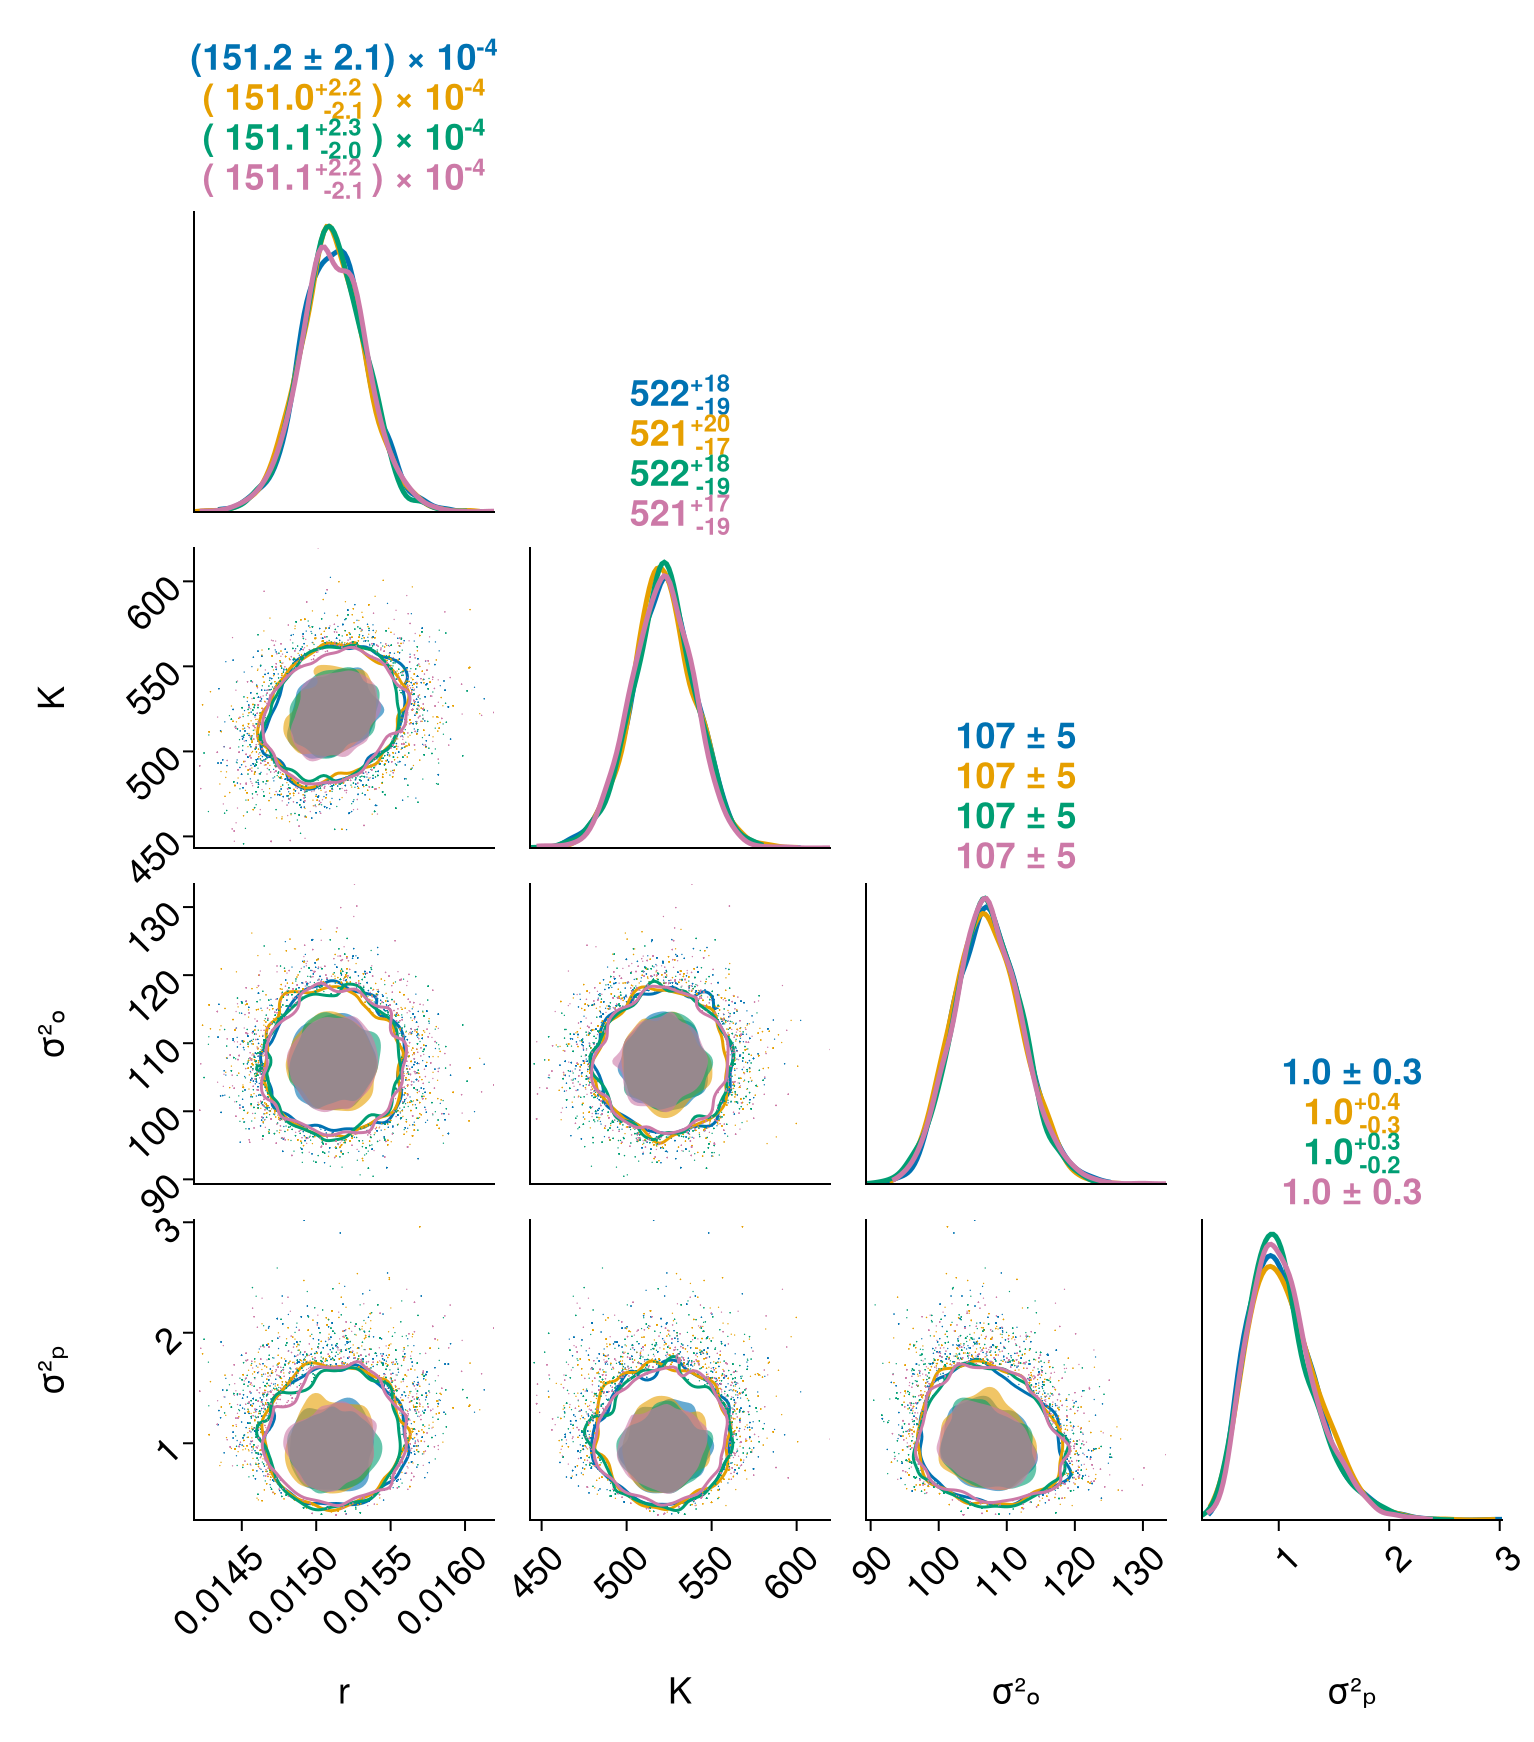

In [113]:
PairPlots.pairplot(chn[:, :, 1], chn[:, :, 2],
                   chn[:, :, 3], chn[:, :, 4])

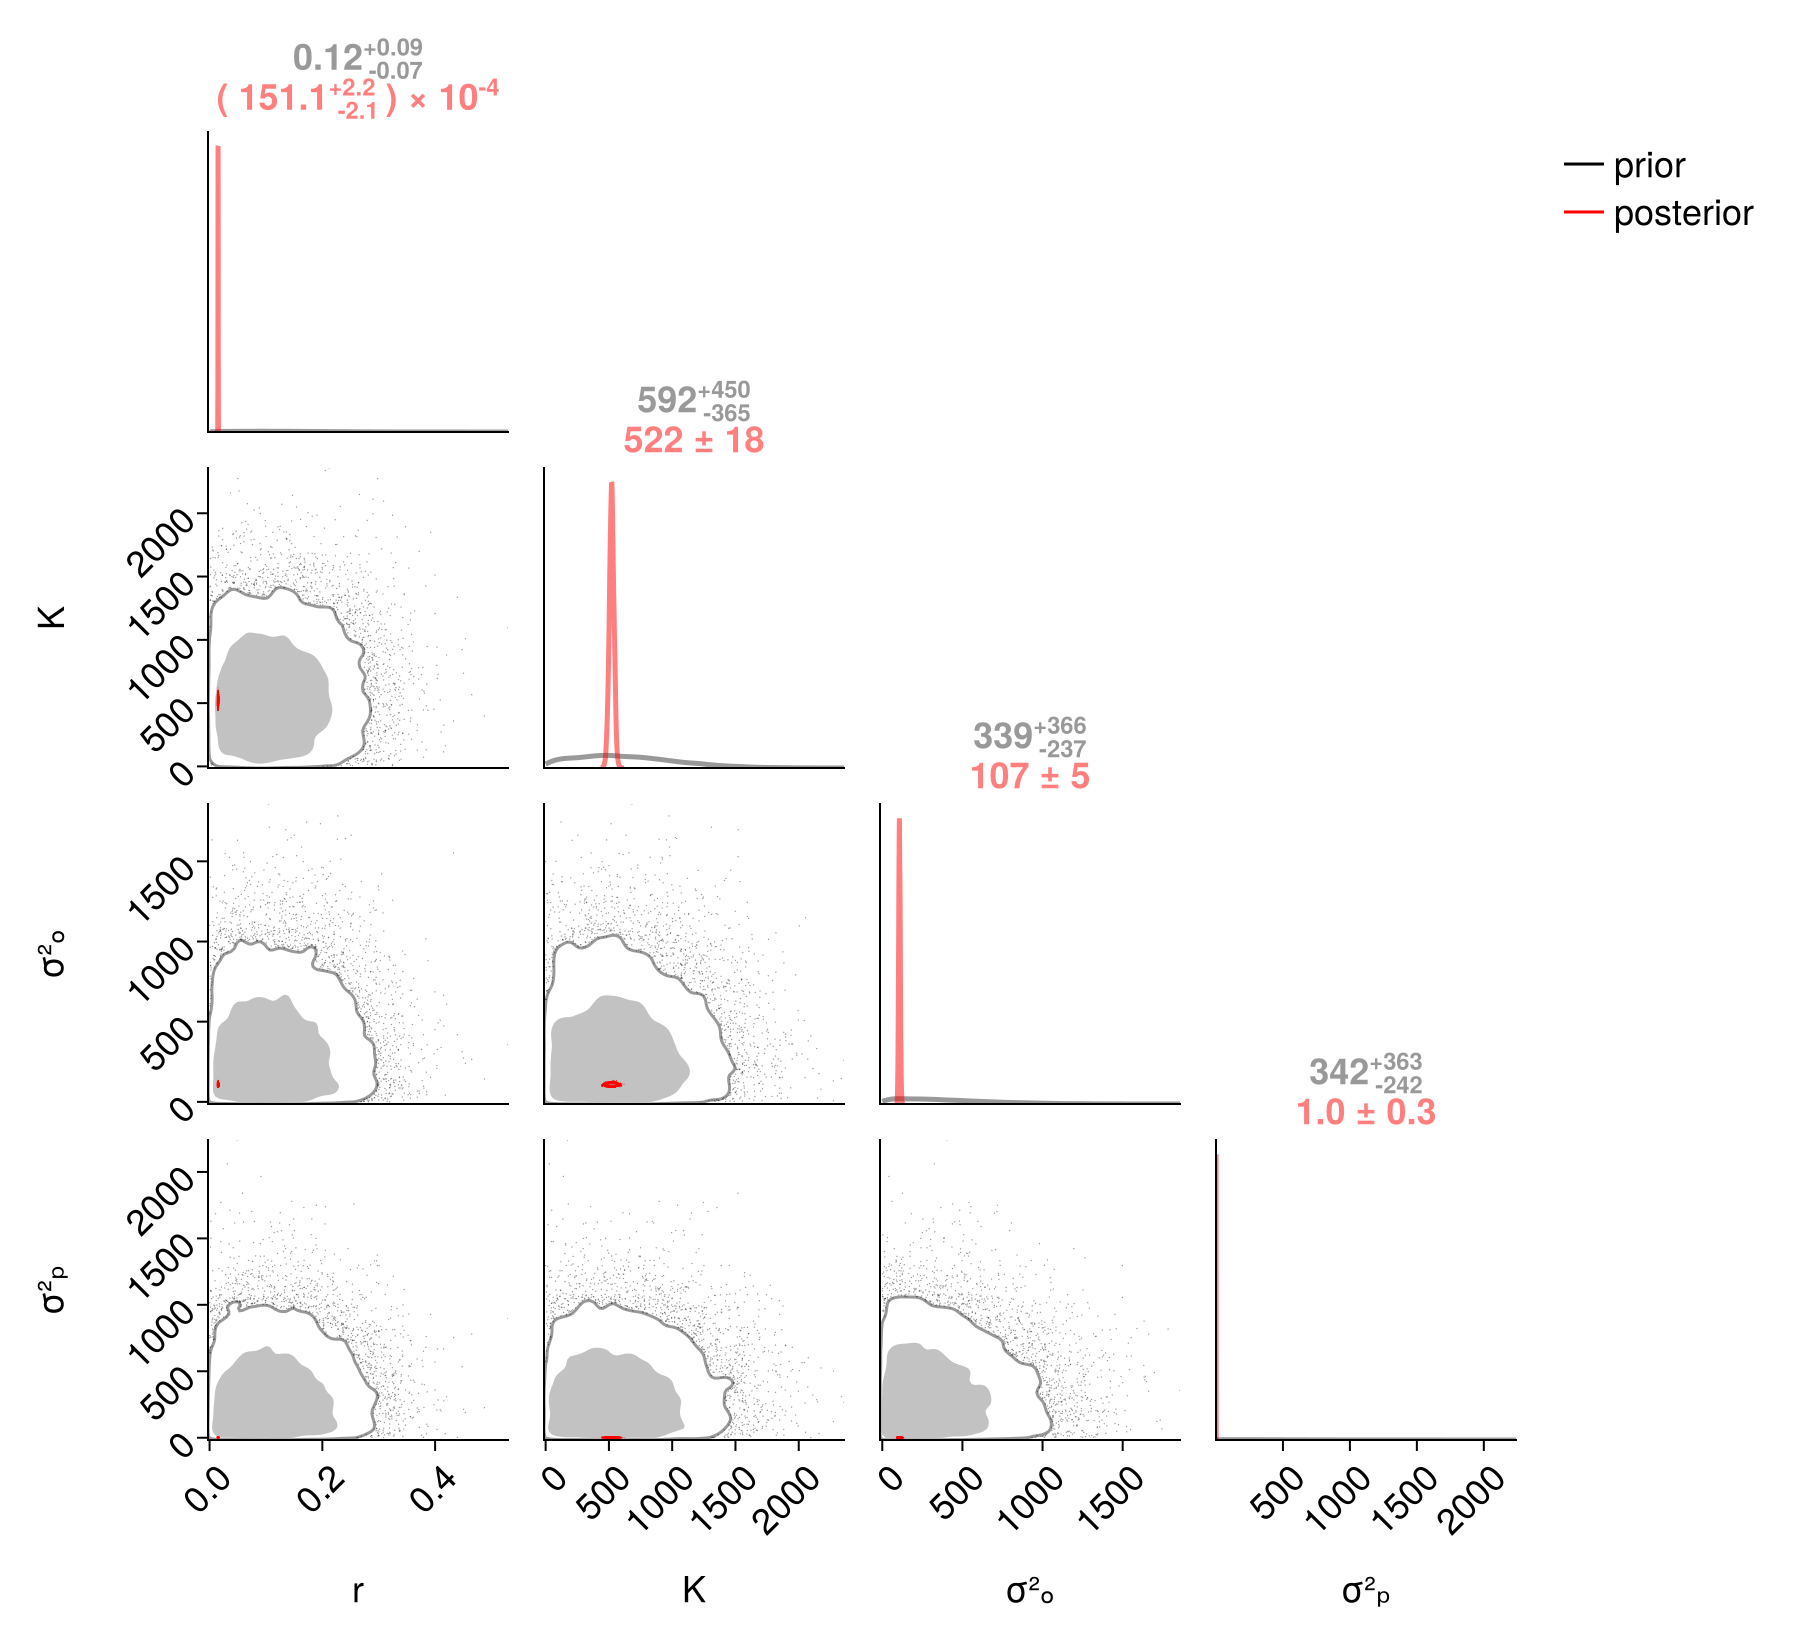

In [114]:
let
    n = 10000
    prior_df = (; zip(keys(my_priors), [rand(my_priors[k], n) for k in keys(my_priors)])...)

    PairPlots.pairplot(
        PairPlots.Series(prior_df, label = "prior", color = (:black, 0.4)),
        PairPlots.Series(chn, label = "posterior", color = (:red, 0.5)))
end

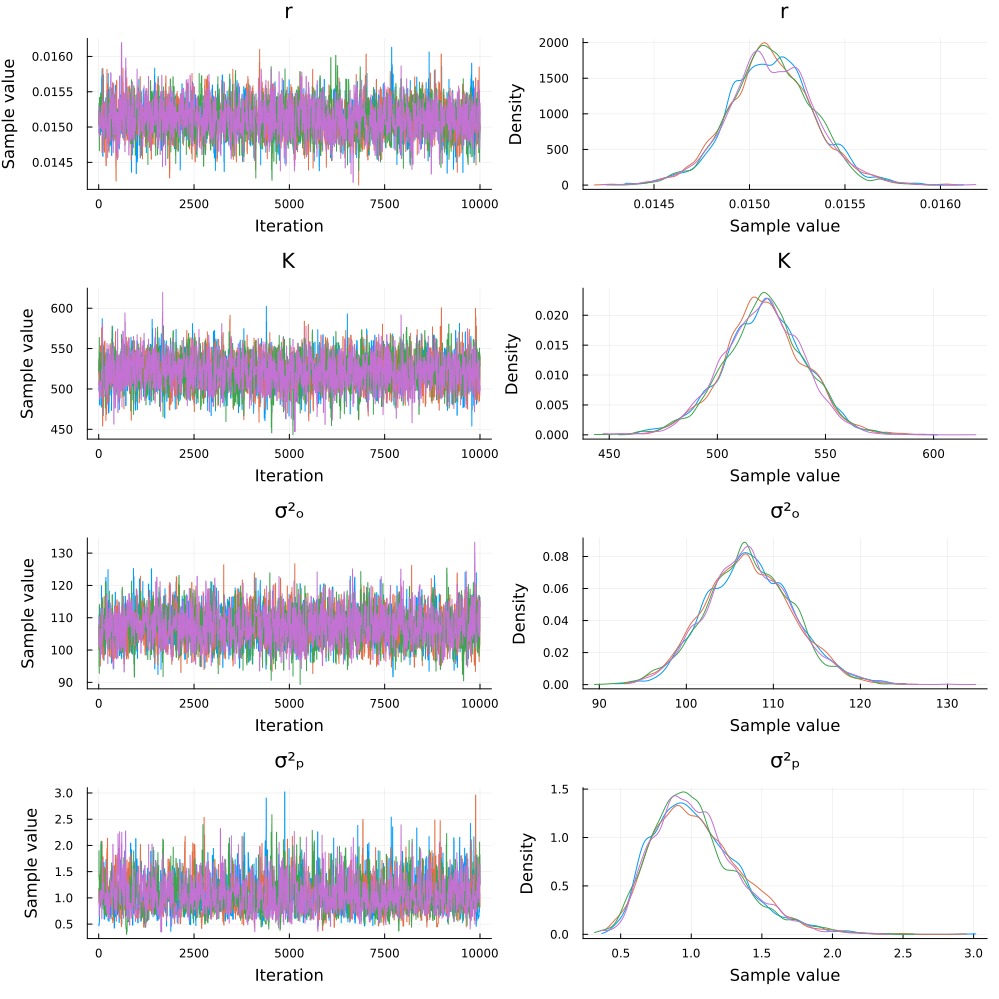

In [115]:
StatsPlots.plot(chn)

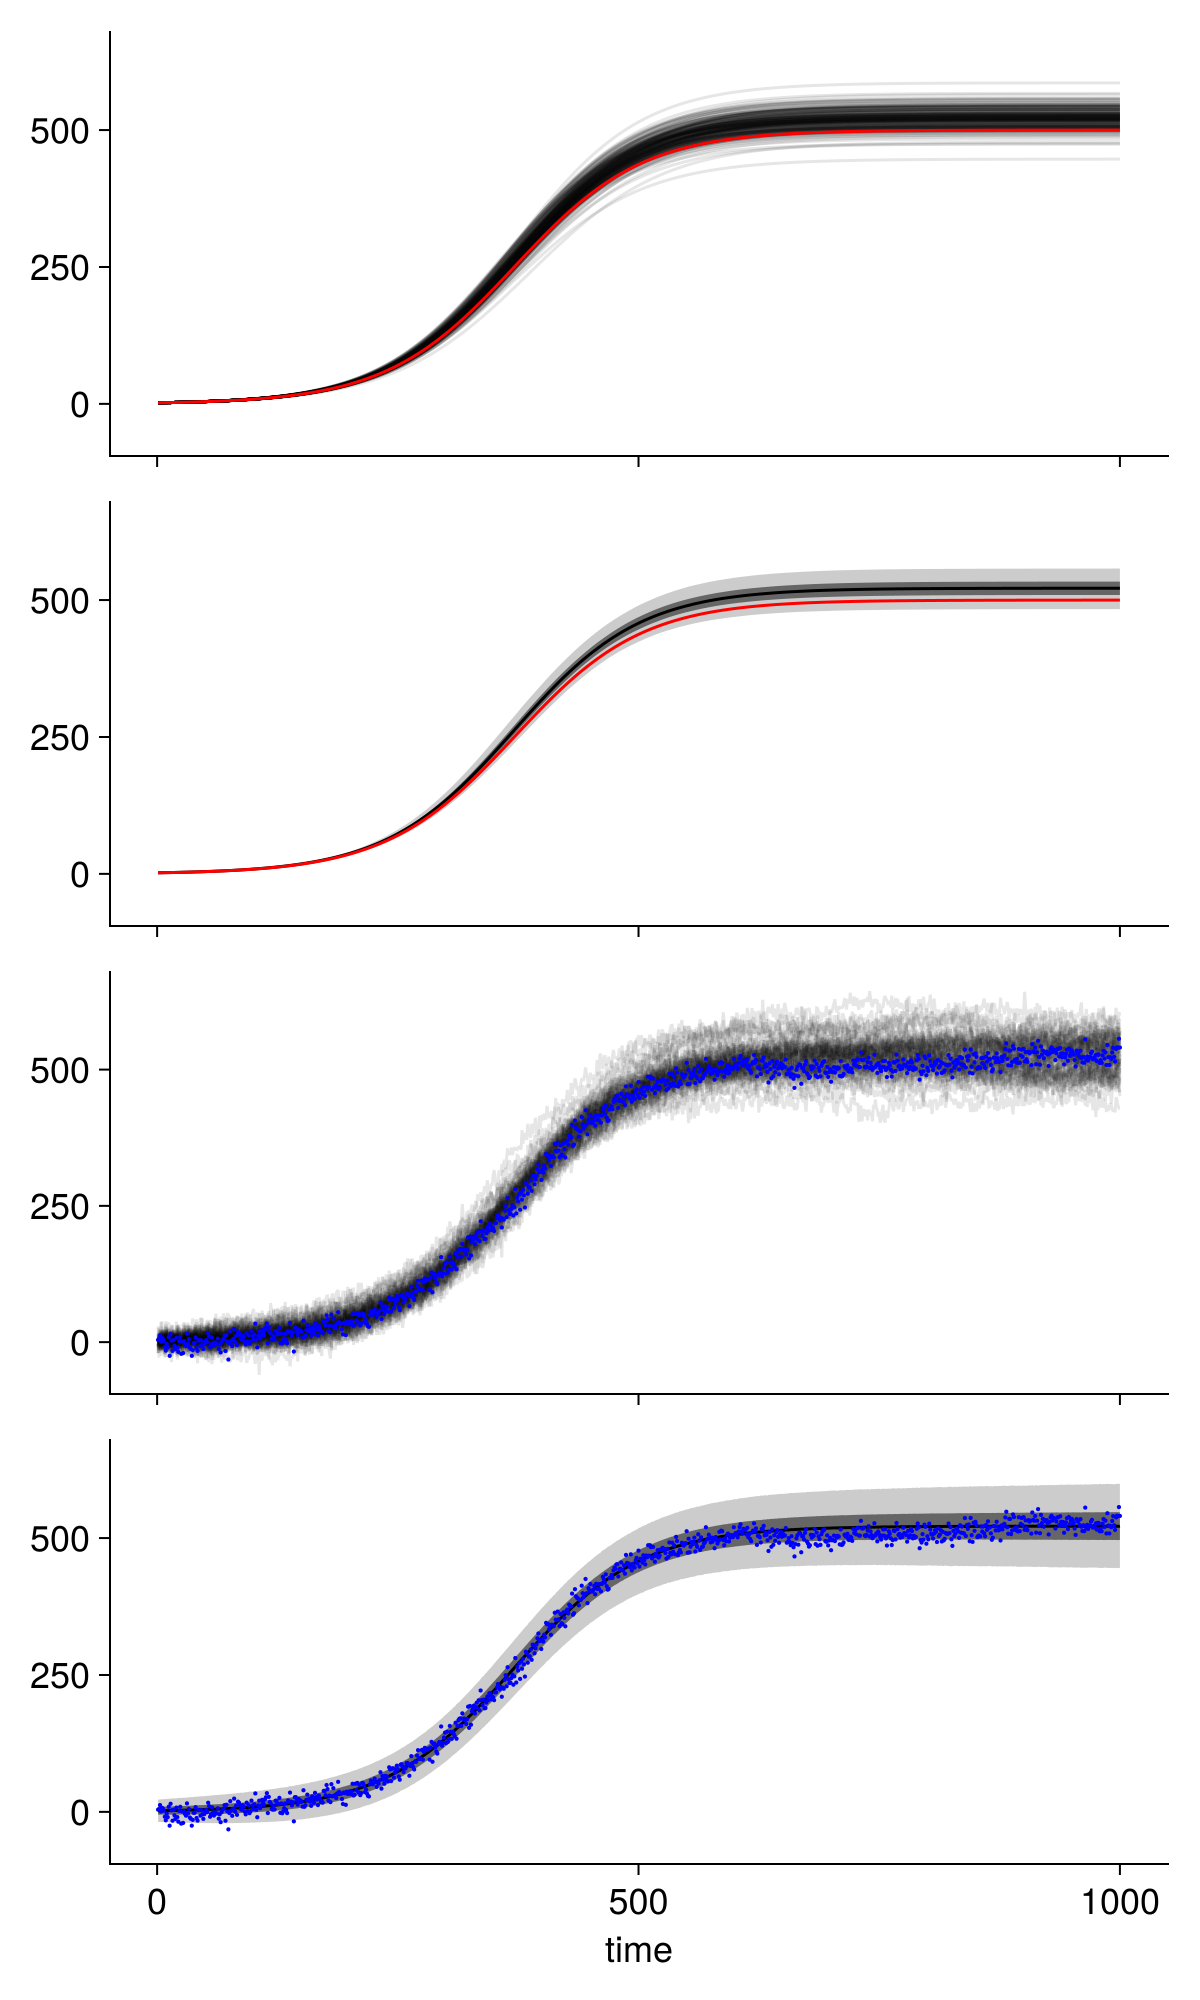

In [122]:
function sample_posterior(data, problem, burnin)
    nchains, nparameter, nsamples = size(data)
    transform(problem.transformation, data[sample(1:nchains), :, sample(burnin:nsamples)])
end

let
    fig = Figure(size = (600, 1000))
    
    ax1 = Axis(fig[1, 1]; xticklabelsvisible = false)
    for i in 1:200
        @unpack r, K = sample_posterior(post_raw, problem, burnin)
        x = zeros(length(problem.ts))
        for t in problem.ts
            x_last = t == 1 ? 2.0 : x[t-1]
            x[t] = (1 + r*(1 - x_last/K)) * x_last
        end
        lines!(1:T, x, color = (:black, 0.1))
    end
    lines!(1:T, x, color = :red)    
    
    
    ax2 = Axis(fig[2, 1]; xticklabelsvisible = false)
    q_post = post_pred(chn, 1:T; noise = false)
    band!(1:T, q_post[:, 1], q_post[:, 5], color = (:black, 0.2))
    band!(1:T, q_post[:, 2], q_post[:, 4], color = (:black, 0.5))
    lines!(1:T, q_post[:, 3], color = :black)
    lines!(1:T, x, color = :red)    
    
    ax3 = Axis(fig[3, 1]; xticklabelsvisible = false)
    for i in 1:50
        @unpack r, K, σ²ₒ, σ²ₚ = sample_posterior(post_raw, problem, burnin)
        x = zeros(length(problem.ts))
        for t in problem.ts
            x_last = t == 1 ? 2.0 : x[t-1]
            x[t] = (1 + r*(1 - x_last/K)) * x_last
        end
        x .+= generate_noise(T, sqrt(σ²ₒ), sqrt(σ²ₚ))
        lines!(1:T, x, color = (:black, 0.1))
    end
    scatter!(1:T, y, color = :blue, markersize = 3) 
    
    ax4 = Axis(fig[4, 1]; xlabel = "time")
    q_post = post_pred(chn, 1:T; noise = true)
    band!(1:T, q_post[:, 1], q_post[:, 5], color = (:black, 0.2))
    band!(1:T, q_post[:, 2], q_post[:, 4], color = (:black, 0.5))
    lines!(1:T, q_post[:, 3], color = :black)
    scatter!(1:T, y, color = :blue, markersize = 3)
   
    linkyaxes!(ax1, ax2, ax3, ax4)
    
    fig
end